In [4]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
H, W = 410, 550 # Image dimensions

**Use in-built cv2 functions for filters, Gaussians, Fourier transforms etc. You do not need to write the operations from scratch.**

## Helper Functions

In [18]:
def make_gradient(H, W):
    """
    Smooth horizontal gradient: pixel value increases linearly from left (0) to right (255).
    """
    row = np.linspace(0, 255, W, dtype=np.float64)
    return np.tile(row, (H, 1))

def make_checkerboard(H, W, tile_size=64):
    """
    Checkerboard pattern with alternating 0/255 tiles of given size.
    Spatial frequency = 1/(2*tile_size) cycles/pixel.
    """
    xs = np.arange(W) // tile_size
    ys = np.arange(H) // tile_size
    xx, yy = np.meshgrid(xs, ys)
    return ((xx + yy) % 2) * 255.0

In [19]:
def read_image(filename, format='gray'):
    """
    Read image from file and convert to specified format.
    """
    basepath = os.path.curdir
    img = cv2.imread(os.path.join(basepath, 'data', 'input', filename))
    if format == 'gray':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    elif format == 'rgb':
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (W, H))
    return img.astype(np.float64)

In [20]:
def psnr(image_true: np.ndarray, image_noisy: np.ndarray) -> float:
    """
    Compute Peak Signal-to-Noise Ratio (PSNR) between two images.
    PSNR = 20 * log10(MAX) - 10 * log10(MSE)

    Parameters:
    image_true: clean reference image
    image_noisy: distorted/filtered image (same shape and dtype)

    Returns:
    PSNR in decibels (dB). Returns np.inf if the images are identical.
    """
    image_true  = image_true.astype(np.float64)
    image_noisy = image_noisy.astype(np.float64)

    mse = np.mean((image_true - image_noisy) ** 2)
    if mse == 0:
        return np.inf

    max_val = 255.0 if image_true.max() > 1.0 else 1.0
    return 20 * np.log10(max_val) - 10 * np.log10(mse)

In [23]:
f1 = make_gradient(H, W)        # smooth gradient
f2 = make_checkerboard(H, W)  # checkerboard pattern
f3 = read_image('natural_image.jpg')  # natural image
f4 = read_image('flower.jpg')    # noisy version of natural image

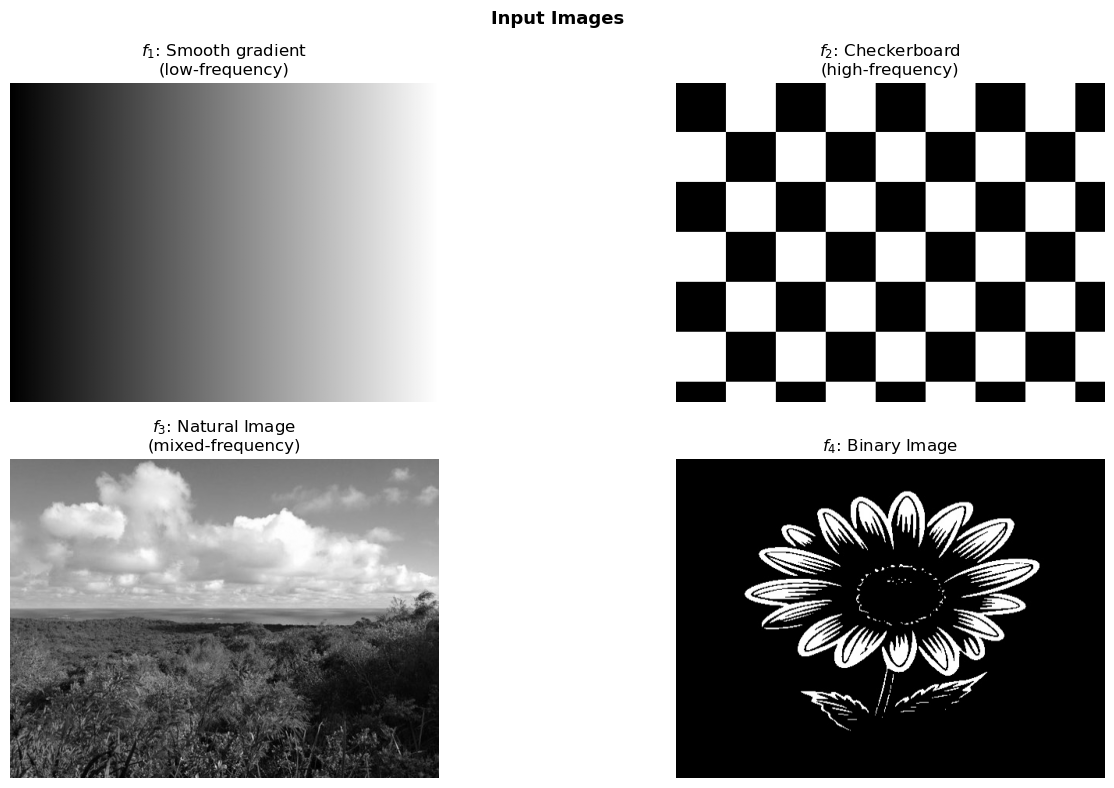

f1 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f2 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f3 shape: (410, 550), dtype: float64, range: [0.0, 255.0]
f4 shape: (410, 550), dtype: float64, range: [0.0, 255.0]


In [22]:
# Visualise the input images
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
axes[0, 0].imshow(f1, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('$f_1$: Smooth gradient\n(low-frequency)', fontsize=12)
axes[0, 0].axis('off')

axes[0, 1].imshow(f2, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('$f_2$: Checkerboard\n(high-frequency)', fontsize=12)
axes[0, 1].axis('off')

axes[1, 0].imshow(f3, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('$f_3$: Natural Image\n(mixed-frequency)', fontsize=12)
axes[1, 0].axis('off')

axes[1, 1].imshow(f4, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('$f_4$: Binary Image', fontsize=12)
axes[1, 1].axis('off')

plt.suptitle('Input Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'f1 shape: {f1.shape}, dtype: {f1.dtype}, range: [{f1.min():.1f}, {f1.max():.1f}]')
print(f'f2 shape: {f2.shape}, dtype: {f2.dtype}, range: [{f2.min():.1f}, {f2.max():.1f}]')
print(f'f3 shape: {f3.shape}, dtype: {f3.dtype}, range: [{f3.min():.1f}, {f3.max():.1f}]')
print(f'f4 shape: {f4.shape}, dtype: {f4.dtype}, range: [{f4.min():.1f}, {f4.max():.1f}]')

## Question 1: Filters and the Superposition Principle
The goal of this question is to verify superposition experimentally and understand what it means for filter composition and kernel design.

### (1a) Verify the superposition property of the Gaussian filter.

You are given two grayscale images **f1** and **f2**. 

1. Apply a Gaussian filter $G_\sigma$ to each, then verify: $G_\sigma[\alpha f_1 + \beta f_2] = \alpha \cdot G_\sigma[f_1] + \beta \cdot G_\sigma[f_2]$

2. Visualize each component. 

3. Compute the pixel-wise difference between the left and right side. What do you observe? How does the $\sigma$ affect the kernel size?

In [25]:
KSIZE = (0, 0) # Let OpenCV compute the kernel size based on sigma

In [38]:
# Linear combination scalar weights
alpha = 0.6
beta = 0.4
sigma = 3.0

# Helper functions
def gaussian_blur(image, sigma, ksize=KSIZE):
    ''' Apply Gaussian blur with given sigma. '''
    return cv2.GaussianBlur(image, ksize, sigmaX=sigma)

def superpose(f1, f2, alpha, beta): 
    '''Linearly combine two images: alpha * f1 + beta * f2. '''
    return alpha * f1 + beta * f2

def compute_diff(lhs, rhs):
    ''' Compute absolute pixel-wise difference between two images. '''
    return np.abs(lhs - rhs)

def verify_diff(lhs, rhs, tol=1e-9): 
    ''' Check if two images are equal within floating-point tolerance. '''
    return np.allclose(lhs, rhs, atol=tol)

def approx_kernel_size(sigma):
    ''' Return the kernel size OpenCV uses for a given sigma. '''
    return 2 * int(round(2 * sigma)) * 1

def print_superposition_report(diff, lhs, rhs, sigma):
    """Print a summary report of the superposition verification."""
    print(f'Sigma                          : {sigma}')
    print(f'Max difference                 : {diff.max():.6e}')
    print(f'Mean difference                : {diff.mean():.6e}')
    print(f'Superposition holds (tol=1e-9) : {verify_diff(lhs, rhs)}')
    print(f'Approx kernel size             : {approx_kernel_size(sigma)}x{approx_kernel_size(sigma)}')

def print_sigma_kernel_table(sigmas=[0.5, 1.0, 2.0, 3.0, 5.0, 10.0]):
    """Print a table of sigma values and their corresponding kernel sizes."""
    print("\nSigma → Kernel size relationship:")
    for s in sigmas:
        k = approx_kernel_size(s)
        print(f"  sigma={s:5.1f}  →  kernel ≈ {k}×{k}")

def plot_superposition(combined, lhs, rhs, g_f1, g_f2, diff, alpha, beta, sigma, save_path=None):
    """Visualize superposition components and difference image."""
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))

    axes[0, 0].imshow(combined, cmap='gray', vmin=0, vmax=255)
    axes[0, 0].set_title(f'Combined input\n$\\alpha f_1 + \\beta f_2$\n(α={alpha}, β={beta})', fontsize=11)
    axes[0, 0].axis('off')

    axes[0, 1].imshow(lhs, cmap='gray', vmin=0, vmax=255)
    axes[0, 1].set_title(f'LHS: $G_\\sigma[\\alpha f_1 + \\beta f_2]$\n(σ={sigma})', fontsize=11)
    axes[0, 1].axis('off')

    axes[0, 2].imshow(rhs, cmap='gray', vmin=0, vmax=255)
    axes[0, 2].set_title(f'RHS: $\\alpha G_\\sigma[f_1] + \\beta G_\\sigma[f_2]$\n(σ={sigma})', fontsize=11)
    axes[0, 2].axis('off')

    axes[1, 0].imshow(g_f1, cmap='gray', vmin=0, vmax=255)
    axes[1, 0].set_title(f'$G_\\sigma[f_1]$ (gradient blurred)\nσ={sigma}', fontsize=11)
    axes[1, 0].axis('off')

    axes[1, 1].imshow(g_f2, cmap='gray', vmin=0, vmax=255)
    axes[1, 1].set_title(f'$G_\\sigma[f_2]$ (checkerboard blurred)\nσ={sigma}', fontsize=11)
    axes[1, 1].axis('off')

    im = axes[1, 2].imshow(diff, cmap='hot')
    axes[1, 2].set_title(f'|LHS − RHS| difference\nmax={diff.max():.2e}, mean={diff.mean():.2e}', fontsize=11)
    axes[1, 2].axis('off')
    plt.colorbar(im, ax=axes[1, 2], fraction=0.046)

    plt.suptitle(f'1a: Gaussian Filter Superposition Verification  (σ={sigma})', fontsize=13, fontweight='bold')
    plt.subplots_adjust(left=0.05, right=0.95, bottom=0.05, top=0.88, wspace=0.3, hspace=0.4)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

Sigma                          : 3.0
Max difference                 : 1.705303e-13
Mean difference                : 2.416534e-14
Superposition holds (tol=1e-9) : True
Approx kernel size             : 12x12

Sigma → Kernel size relationship:
  sigma=  0.5  →  kernel ≈ 2×2
  sigma=  1.0  →  kernel ≈ 4×4
  sigma=  2.0  →  kernel ≈ 8×8
  sigma=  3.0  →  kernel ≈ 12×12
  sigma=  5.0  →  kernel ≈ 20×20
  sigma= 10.0  →  kernel ≈ 40×40


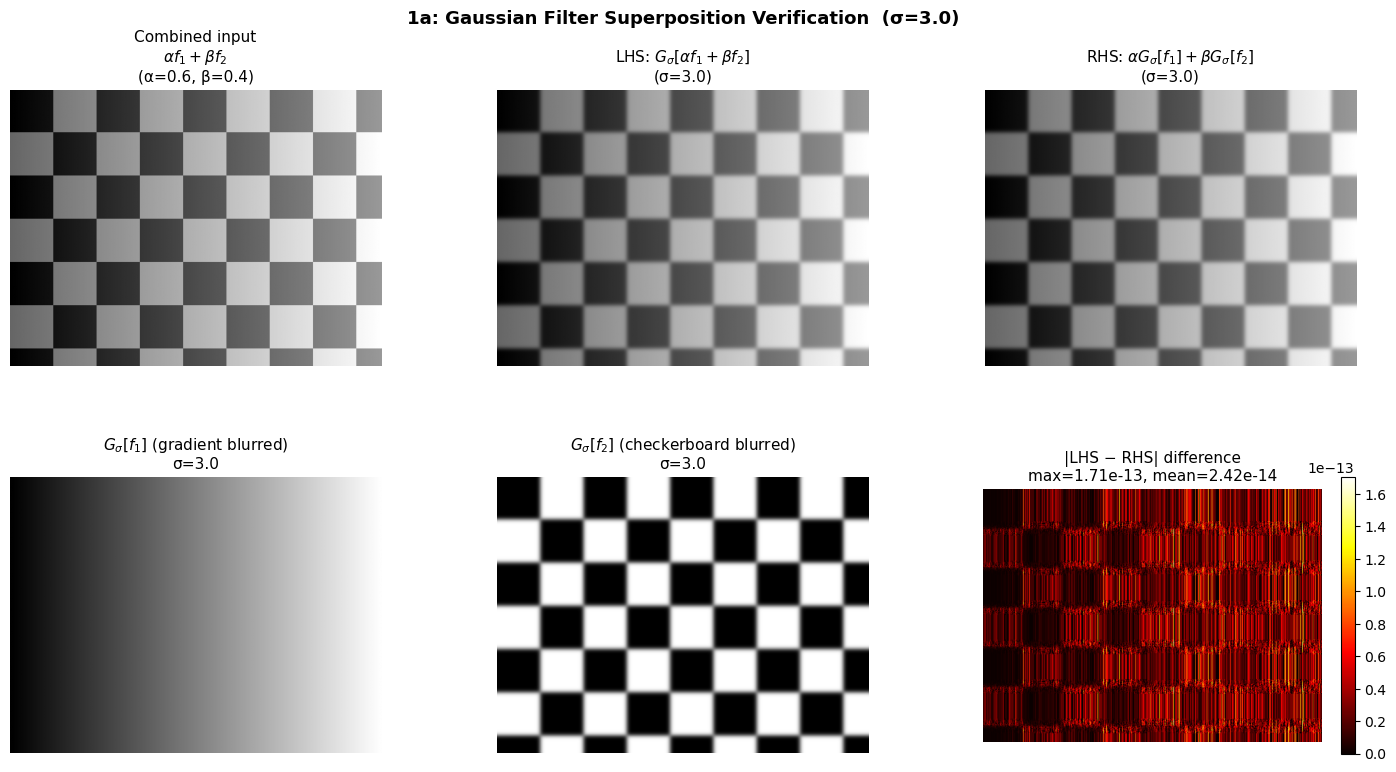

In [39]:
# LHS: blur the combined image
combined = superpose(f1, f2, alpha, beta)
lhs = gaussian_blur(combined, sigma)

# RHS: blur individually, then combine
g_f1 = gaussian_blur(f1, sigma)
g_f2 = gaussian_blur(f2, sigma)
rhs = superpose(g_f1, g_f2, alpha, beta)

# Difference
diff = compute_diff(lhs, rhs)

# Report & plot
print_superposition_report(diff, lhs, rhs, sigma)
print_sigma_kernel_table()
plot_superposition(combined, lhs, rhs, g_f1, g_f2, diff, alpha, beta, sigma,
                   save_path='data/output/q1a_superposition.png')

## Answer:
**1. Applying the Gaussian filter and verifying superposition**

To verify superposition, I applied a Gaussian filter with $\sigma$=3.0 to the combined image $\alpha f_1 + \beta f_2$ (LHS), and separately filtered $f_1$ and $f_2$ before combining them as $\alpha \cdot G_\sigma[f_1] + \beta \cdot G_\sigma[f_2]$ (RHS). The results show that both sides are visually identical, confirming that the Gaussian filter satisfies the superposition principle. This is expected because the Gaussian filter is a linear operation, as it works by convolving the image with a fixed kernel, and convolution distributes over both addition and scalar multiplication.

---

**2. Visualizing each component**

Looking at the visualizations, the combined input shows both the gradient and checkerboard patterns mixed together. After filtering, the LHS and RHS panels appear completely identical. The checkerboard edges are softened while the gradient remains largely unchanged. This makes sense because the gradient in $f_1$ is a low-frequency signal that a smoothing filter barely affects, whereas the sharp edges of the checkerboard in $f_2$ carry high-frequency content that the Gaussian suppresses.

---

**3. Pixel-wise difference and effect of sigma**

The pixel-wise difference between LHS and RHS gives a maximum of $1.71e-13$ and a mean of $2.42e-14$, which are effectively zero. The np.allclose check confirms superposition holds well within the tolerance of $1e-9$. The tiny non-zero values are not a real violation of linearity. They are purely floating-point rounding errors that arise from the non-associativity of finite-precision arithmetic when operations are performed in different orders. The faint vertical stripe pattern visible in the difference image simply reflects the horizontal structure of $f_1$ as a floating-point artefact and carries no meaningful signal.

Regarding the effect of sigma, OpenCV determines the kernel size automatically from sigma using the approximation $k = 2 * round(2 * \sigma) + 1$, meaning the kernel grows linearly with sigma. For example, $\sigma$ = 1 gives a 4x4 kernel while $\sigma$ = 10 gives a 40x40 kernel. A larger $\sigma$ produces a wider Gaussian bell curve, meaning more neighbouring pixels contribute to each output value, resulting in stronger blurring. High-frequency content like the checkerboard edges gets increasingly suppressed as $\sigma$ grows, while low-frequency content like the smooth gradient is largely unaffected regardless of the kernel size.

### (1b) Filter combination

Implement the following two-step pipeline sequentially on **f3**:

1. Apply a Gaussian blur with $\sigma = 1.5$
2. Apply a sharpening (unsharp mask) with $\alpha = 1.0$

Then, using the algebra from the lecture, derive the **single equivalent kernel** $k = (1+\alpha)e - \alpha G_\sigma$​ and apply it in one convolution step. 

Show that the outputs are identical (up to floating point tolerance). Compare the runtime of both approaches.

### (1c) Median filter
Repeat the superposition experiment from 1(a), but now with a median filter. Compute:

$\text{Median}[\alpha f_1 + \beta f_2] \quad \text{vs.} \quad \alpha \cdot \text{Median}[f_1] + \beta \cdot \text{Median}[f_2]$

Visualize the difference image. Is superposition satisfied? Where are the largest differences spatially, at edges, or in flat regions? Why?

## Question 2: Understanding and Handling Noise

The goal here is to understand filters across noise types and content types.

### (2a) Noise robustness comparison

Corrupt the grayscale image **f3** with three noise types:

* Gaussian noise (use np.random.normal)
* Salt-and-pepper noise (randomly set pixels to 0 or 255)
* Impulse noise (randomly set pixels to 255 only)

Apply both a Gaussian filter and a median filter to each noisy image.

Visualize each noise type × filter and discuss: which filter is suitable for which noise type, and why based on the properties of each filter?

Compute PSNR (peak signal-to-noise ratio) against the clean original for all combinations. Validate you observations (Higher the PSNR value, lower the noise).

### (2b) Morphological filters for noise removal 

Corrupt **f4** with salt-and-pepper noise. Apply morphological opening, closing, and opening+closing using structuring elements of 2 different sizes. 

Answer:

* Which operation is necessary for salt noise, and pepper noise individually and combined?
* What happens to fine image structures as structuring element size increases?
* Can you combine morphological filtering with a subsequent Gaussian to further improve quality? Try it and show the result.

## Question 3 - Fourier Transformations

The goal here is to understand the effects of Fourier transforms and operations in the Fourier space.

### (3a) Fourier Transform

Compute the 2D Fourier Transform of **f2** and **f3**. Visualize the log magnitude spectrum of both.
1. What differences do you observe between the frequency spectra of the checkerboard and the natural image?
2. What does this tell you about their spatial structure?

### (3b) Effect of Gaussian Blur

Apply Gaussian blur to both images **f2** and **f3**. Compute and visualize their log magnitude spectrum again.
1. How does Gaussian blur affect the frequency spectrum?
2. Exlain why these changes occur in frequency space.

### (3c) Frequency Filtering
Apply to both images:
* Low-pass filter
* High-pass filter

Observe and analyse:
1. Changes in spatial domain
2. Changes in frequency domain

### (3d) Phase vs Magnitude
Reconstruct the original images **f2** and **f3** using:
* Original FFT (magnitude + phase) 
* Phase only (constant magnitude)
* Magnitude only (random phase)

Cross swap:
* Magnitude of **f3** + Phase of **f2**
* Magnitude of **f2** + Phase of **f3**

1. Which component (phase or magnitude) better preserves image structure?
2. Justify using your results.